In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(repr))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donor_order <- c('C29', 'C37', 'C38', 'C39')

tmp_order <- c('Start', 'Sendai', 'Skin', 'Inflamed', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#3CADBA', '#83E880', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

umap_theme <- theme(
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### C: cell state proportion per day

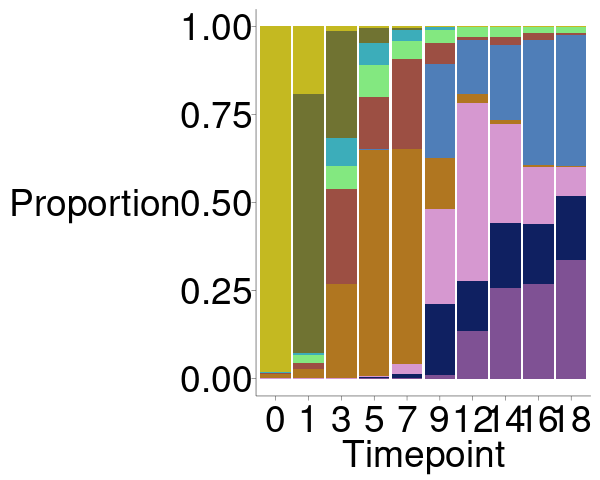

In [ ]:
clust_path = paste0(projdir, '/csv/figure1/clust_time_dist.csv')
clusters = as.data.frame(fread(clust_path, sep='\t'))
clusters$variable <- factor(clusters$variable, levels=tmp_order)
clusters$cluster <- factor(clusters$cluster)

w = 5
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(clusters, aes(x = cluster, y = value, fill = variable)) +
  geom_bar(stat = 'identity') +
  labs(x = "Timepoint", y = "Proportion", fill='Cluster') +
  theme_bw() +
  umap_theme +
   theme(axis.text.x = element_text(size=22,angle=0, color='black'),
        axis.text.y = element_text(size=22,angle=0, color='black'),
        axis.title.x = element_text(size=22),
        axis.title.y = element_text(size=22, angle=90),
        axis.line.x = element_line(linewidth=0.1),
        axis.line.y = element_line(linewidth=0.1),
        axis.ticks.x = element_line(linewidth=0.1),
        axis.ticks.y = element_line(linewidth=0.1),
         legend.position = 'none') +
        scale_fill_manual(values = clust_hexes)

### D: 10x Multiome RNA UMAP

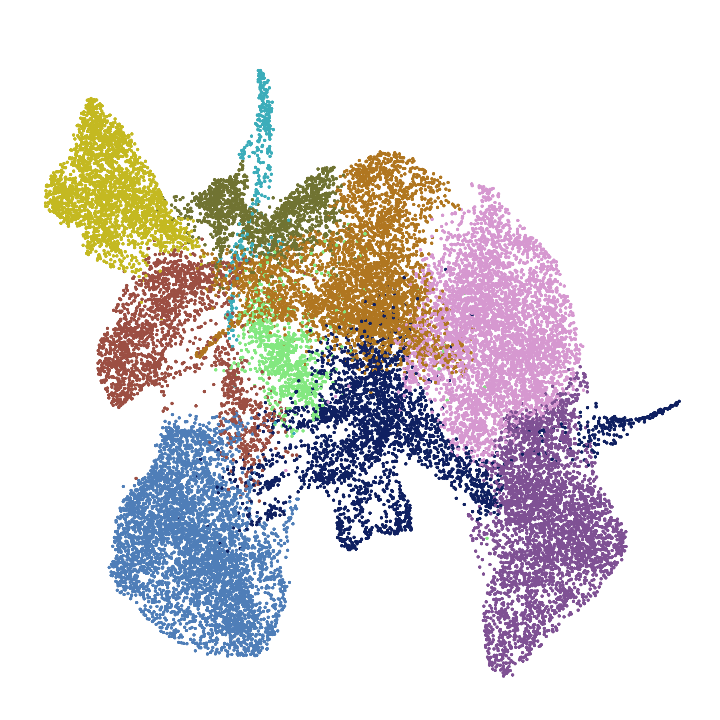

In [ ]:
rna_path = paste0(projdir, '/csv/figure1/rna_umap_meta.csv')
rna_umap = read.csv(rna_path, sep='\t')
rna_umap$assignment <- factor(rna_umap$assignment, level=donor_order)
rna_umap$coarse <- factor(rna_umap$coarse, levels=tmp_order)

w = 6
h = 6
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_rna_umap <- rna_umap[sample(nrow(rna_umap)), ]

ggplot(shuffled_rna_umap, aes(x = umap0, y = umap1, color = coarse)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", title='') +
  theme_bw() +
  umap_theme +
        scale_color_manual(values = clust_hexes)

### E: snmCT-seq RNA UMAP

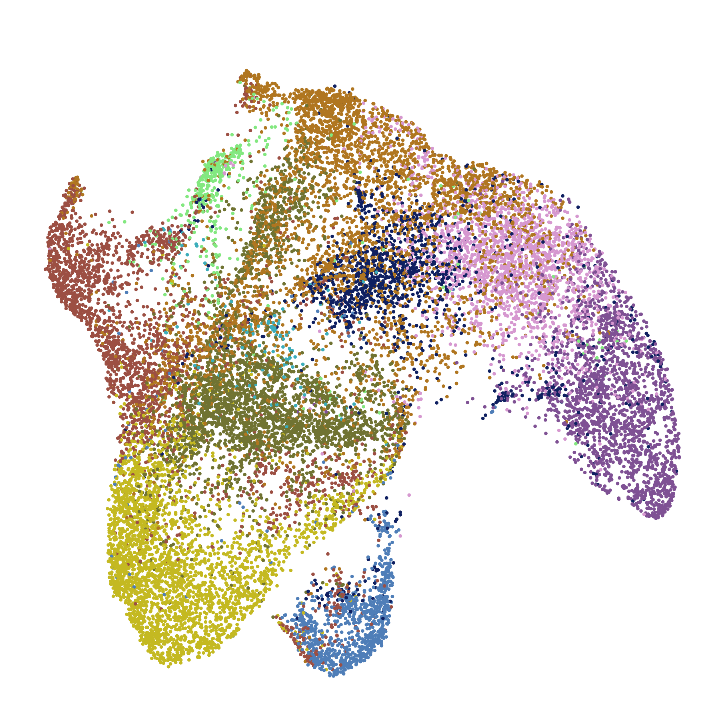

In [ ]:
snmct_path = paste0(projdir, '/csv/figure1/snmct_umap_meta.csv')
snmct_umap = read.csv(snmct_path, sep='\t')
snmct_umap$coarse <- factor(snmct_umap$coarse, levels=tmp_order)

w = 6
h = 6
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_snmct_umap <- snmct_umap[sample(nrow(snmct_umap)), ]

ggplot(shuffled_snmct_umap, aes(x = umap0, y = umap1, color = coarse)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", title='') +
  theme_bw() +
  umap_theme +
        scale_color_manual(values = clust_hexes)

### F: snm3C-seq 3C UMAP

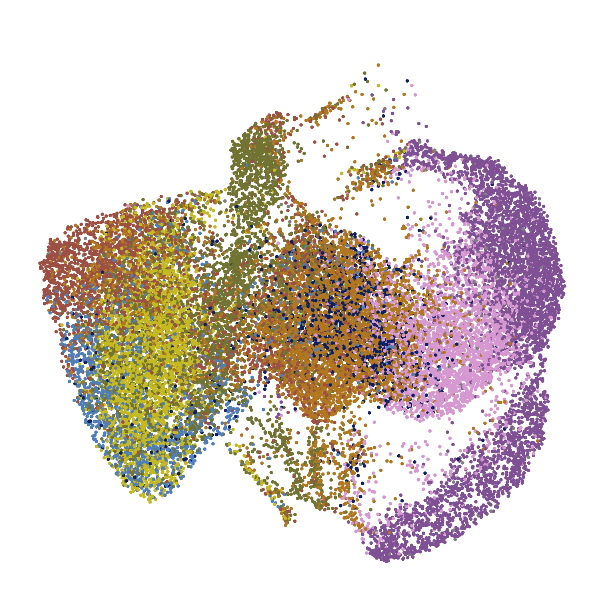

In [ ]:
snm3c_higashi_umap_path = paste0(projdir, '/csv/figure1/snm3c_higashi_umap.csv')
snm3c_higashi_umap = as.data.frame(fread(snm3c_higashi_umap_path, sep='\t'))
snm3c_higashi_umap$cluster <- factor(snm3c_higashi_umap$cluster, levels=tmp_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_snm3c_higashi_umap <- snm3c_higashi_umap[sample(nrow(snm3c_higashi_umap)), ]

ggplot(shuffled_snm3c_higashi_umap, aes(x = umap0, y = umap1, color = cluster)) +
  geom_point_rast(size = 0.1) +
labs(x = "", y = "", color = 'Cluster', title='') +
  theme_bw() +
   umap_theme +
    scale_color_manual(values=clust_hexes)

In [ ]:
sessionInfo()

In [ ]:
Sys.time()